In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve

In [ ]:
 # 1. Setup Plot Style & Load Data
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
data = pd.read_csv("advertising.csv")

Text(0.5, 0, 'Age')

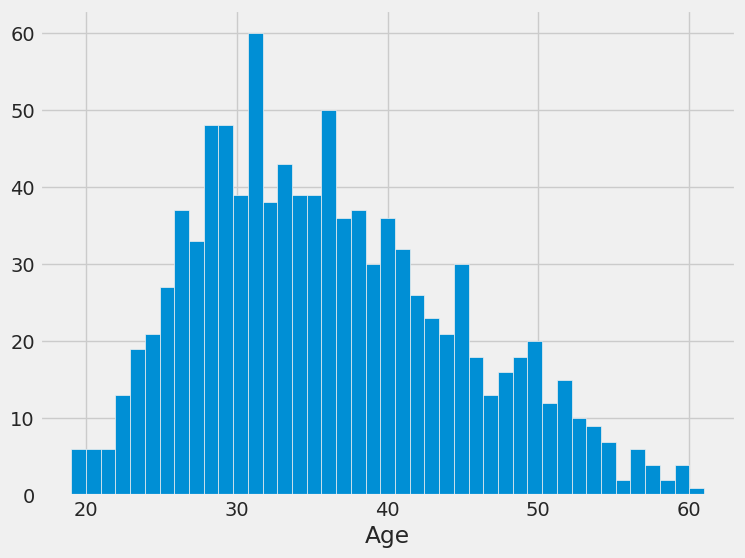

In [ ]:
# 2. Exploratory Data Analysis (Visualization)
# Age Distribution
plt.figure(figsize=(8, 6))
data['Age'].hist(bins=data['Age'].nunique())
plt.xlabel('Age')

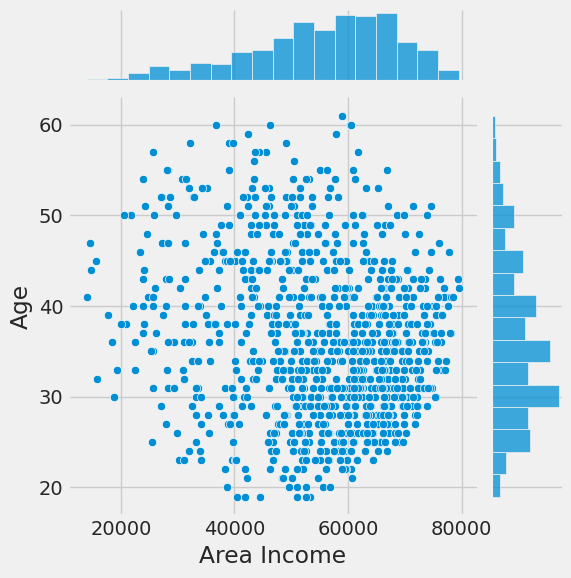

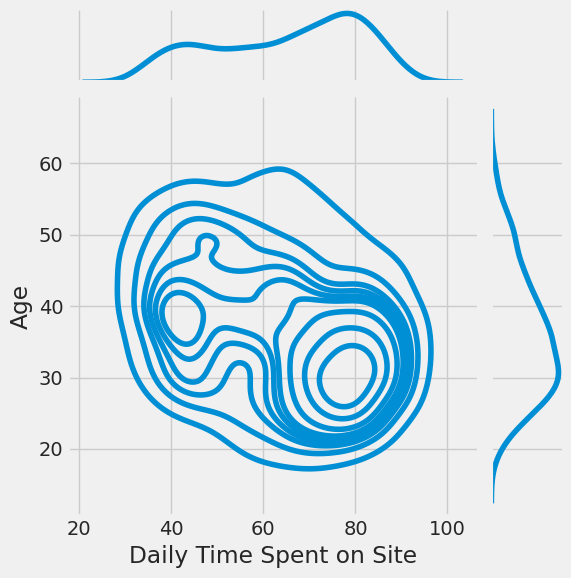

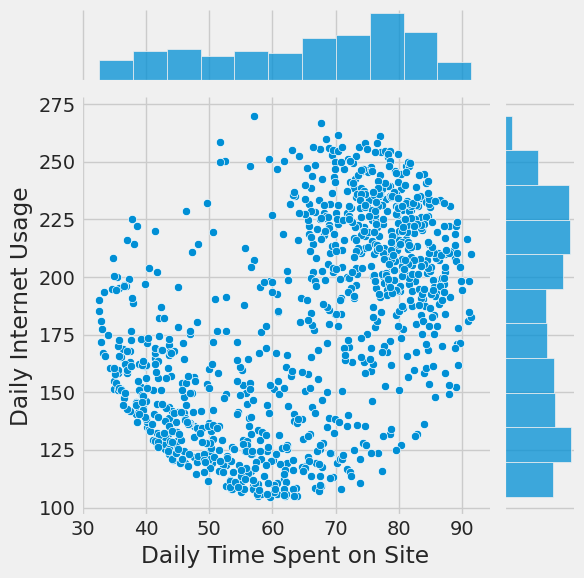

In [ ]:
# Jointplots
sns.jointplot(x=data["Area Income"], y=data['Age'])
sns.jointplot(x=data["Daily Time Spent on Site"], y=data['Age'], kind='kde')
sns.jointplot(x=data["Daily Time Spent on Site"], y=data["Daily Internet Usage"])

Target Class Counts:
 Clicked on Ad
0    500
1    500
Name: count, dtype: int64


Text(0.5, 1.0, 'Sigmoid Function')

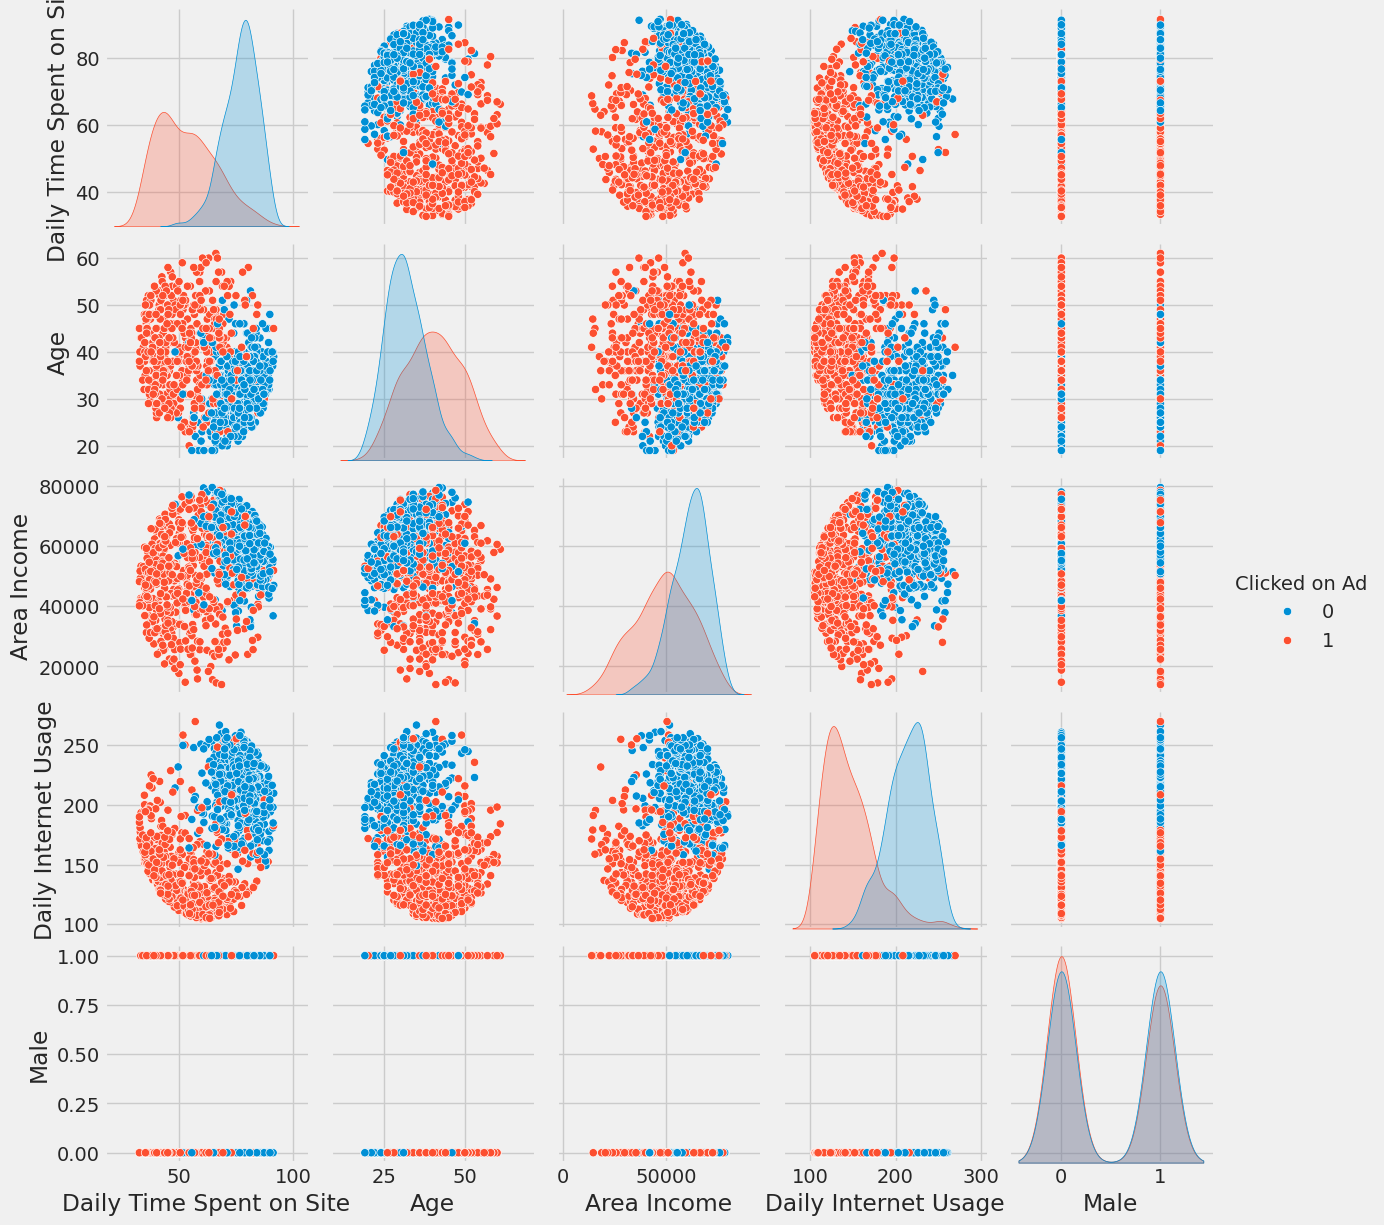

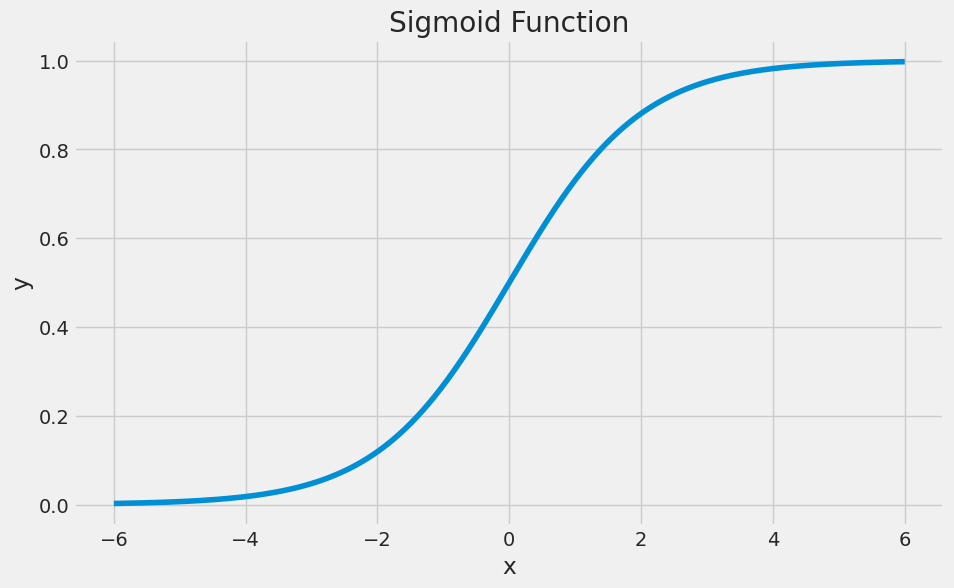

In [ ]:
# Pairplot & Target Counts
sns.pairplot(data, hue='Clicked on Ad')
print("Target Class Counts:\n", data['Clicked on Ad'].value_counts())

# Sigmoid Function Demonstration
x = np.linspace(-6, 6, num=1000)
plt.figure(figsize=(10, 6))
plt.plot(x, (1 / (1 + np.exp(-x))))
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sigmoid Function")

In [ ]:
# 3. Data Preprocessing & Train-Test Split
X = data.drop(['Timestamp', 'Clicked on Ad', 'Ad Topic Line', 'Country', 'City'], axis=1)
y = data['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

num_columns = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']

ct = make_column_transformer(
    (MinMaxScaler(), num_columns),
    (StandardScaler(), num_columns),
    remainder='passthrough'
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [ ]:
# 4. Helper Function for Model Evaluation
def print_score(clf, X_train, y_train, X_test, y_test, train=True):
    if train:
        pred = clf.predict(X_train)
        clf_report = pd.DataFrame(classification_report(y_train, pred, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(y_train, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, pred)}\n")
    else:
        pred = clf.predict(X_test)
        clf_report = pd.DataFrame(classification_report(y_test, pred, output_dict=True))
        print("Test Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(y_test, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_test, pred)}\n")

In [ ]:
# 5. Train Model & Evaluate
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)
print_score(lr_clf, X_train, y_train, X_test, y_test, train=True)
print_score(lr_clf, X_train, y_train, X_test, y_test, train=False)

Train Result:
Accuracy Score: 97.43%
_______________________________________________
CLASSIFICATION REPORT:
                    0           1  accuracy   macro avg  weighted avg
precision    0.964088    0.985207  0.974286    0.974648      0.974527
recall       0.985876    0.962428  0.974286    0.974152      0.974286
f1-score     0.974860    0.973684  0.974286    0.974272      0.974279
support    354.000000  346.000000  0.974286  700.000000    700.000000
_______________________________________________
Confusion Matrix: 
 [[349   5]
 [ 13 333]]

Test Result:
Accuracy Score: 97.00%
_______________________________________________
CLASSIFICATION REPORT:
                    0           1  accuracy   macro avg  weighted avg
precision    0.959732    0.980132      0.97    0.969932      0.970204
recall       0.979452    0.961039      0.97    0.970246      0.970000
f1-score     0.969492    0.970492      0.97    0.969992      0.970005
support    146.000000  154.000000      0.97  300.000000    300.

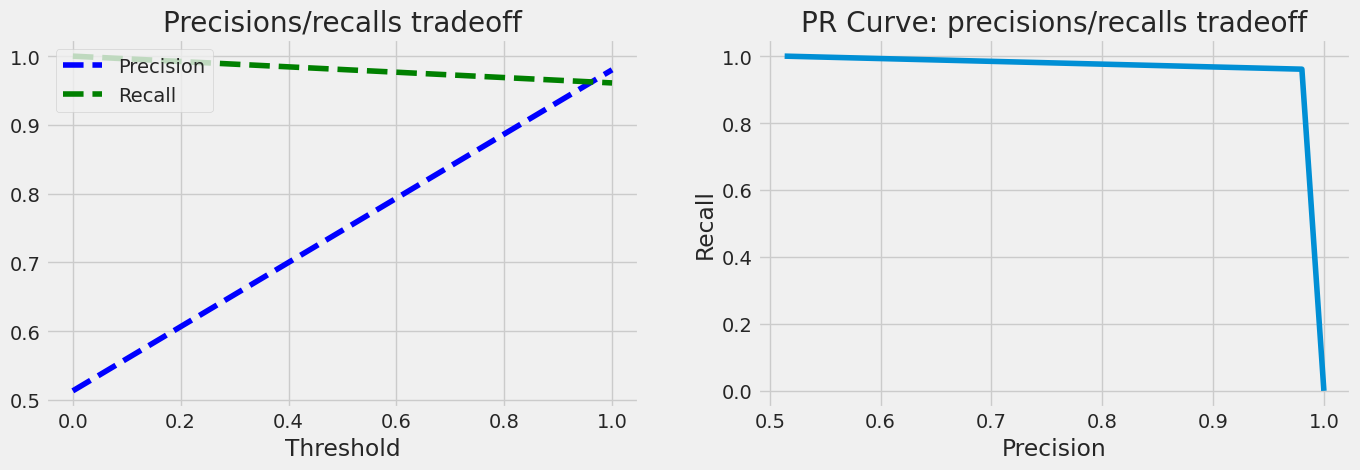

In [ ]:
# 6. Precision / Recall Tradeoff Plot
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.title("Precisions/recalls tradeoff")
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_clf.predict(X_test))
plt.figure(figsize=(15, 10))


plt.subplot(2, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.subplot(2, 2, 2)
plt.plot(precisions, recalls)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("PR Curve: precisions/recalls tradeoff")
plt.show()

# Softmax Regression


Age Group Distribution
Age_Group
Young     363
Senior    325
Middle    312
Name: count, dtype: int64


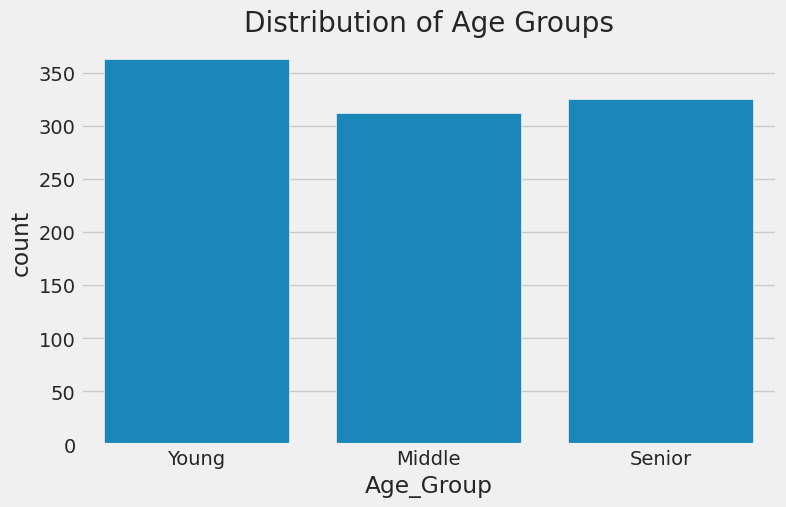

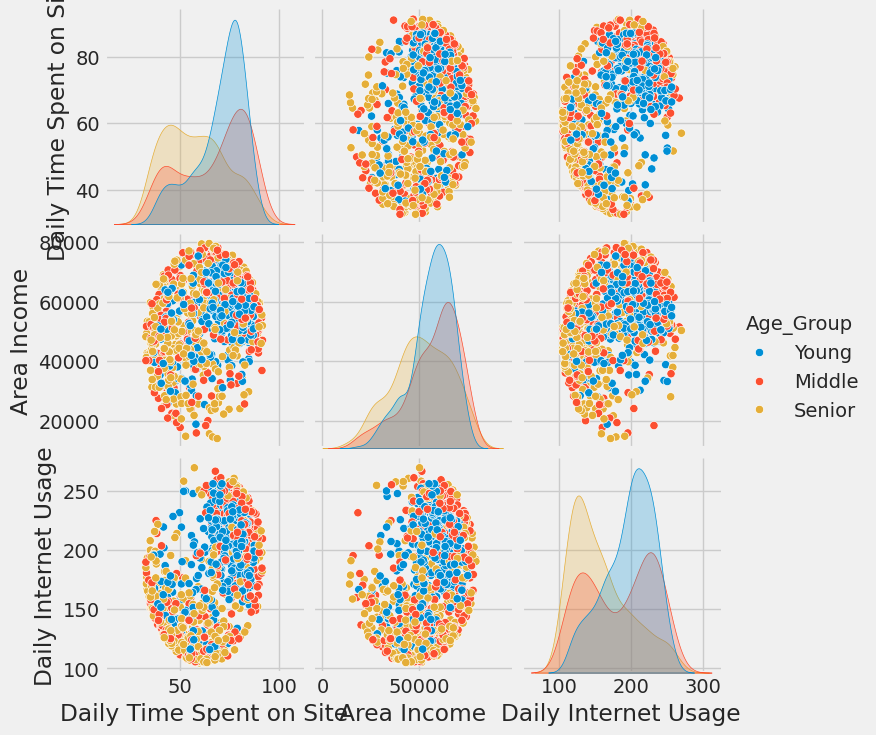


Intercept
[ 0.03099877 -0.11504348  0.08404471]

Coefficients
        Daily Time  Area Income  Internet Usage
Middle    0.087517     0.110805        0.015779
Senior   -0.321799    -0.061749       -0.389068
Young     0.234282    -0.049056        0.373289

First 10 Predictions
   Actual Predicted
0   Young     Young
1  Middle     Young
2   Young     Young
3   Young     Young
4  Middle    Senior
5   Young     Young
6  Middle     Young
7   Young     Young
8   Young     Young
9   Young     Young

Predicted Probabilities (First 5 Samples)
     Middle    Senior     Young
0  0.335417  0.126987  0.537596
1  0.360433  0.132768  0.506799
2  0.382185  0.172727  0.445088
3  0.308236  0.243320  0.448444
4  0.220332  0.587515  0.192153

Accuracy : 49.67%

Classification Report
              precision    recall  f1-score   support

      Middle       0.08      0.01      0.02        94
      Senior       0.53      0.71      0.61        97
       Young       0.50      0.72      0.59       109

    accu

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
data['Age_Group'] = pd.qcut(
    data['Age'],
    q=3,
    labels=['Young', 'Middle', 'Senior']
)
print("\nAge Group Distribution")
print(data['Age_Group'].value_counts())

# Exploratory Data Analysis

plt.figure(figsize=(8,5))
sns.countplot(x='Age_Group', data=data)
plt.title("Distribution of Age Groups")
plt.show()

sns.pairplot(
    data,
    vars=['Daily Time Spent on Site',
          'Area Income',
          'Daily Internet Usage'],
    hue='Age_Group'
)

plt.show()

# Select Features and Target

X = data[['Daily Time Spent on Site',
          'Area Income',
          'Daily Internet Usage']]

y = data['Age_Group']

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Train Softmax Regression Model
softmax_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
softmax_model.fit(X_train, y_train)

# Model Parameters

print("\nIntercept")
print(softmax_model.intercept_)
print("\nCoefficients")
print(pd.DataFrame(
    softmax_model.coef_,
    columns=['Daily Time',
             'Area Income',
             'Internet Usage'],
    index=softmax_model.classes_
))

# Predictions

y_pred = softmax_model.predict(X_test)
print("\nFirst 10 Predictions")
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
print(results.head(10))

# Class Probabilities
prob = softmax_model.predict_proba(X_test)
print("\nPredicted Probabilities (First 5 Samples)")
print(pd.DataFrame(
    prob,
    columns=softmax_model.classes_
).head())

#  Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy : {:.2f}%".format(accuracy*100))

# Classification Report

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Confusion Matrix
[[ 1 37 56]
 [ 4 69 24]
 [ 7 23 79]]


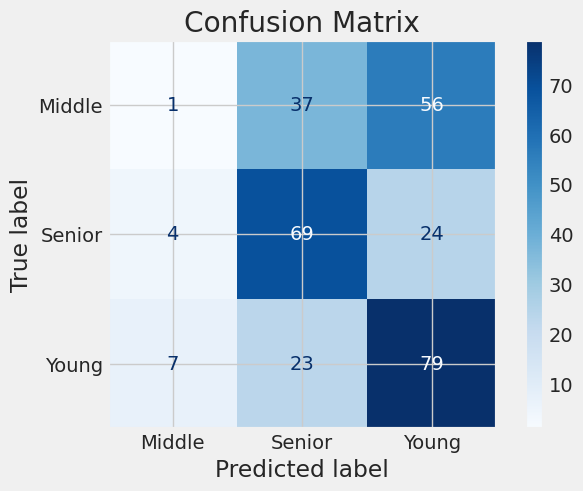

In [ ]:
# 16. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)



disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=softmax_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Prediction for New Sample

new_data = np.array([[70,60000,220]])
new_data = scaler.transform(new_data)
prediction = softmax_model.predict(new_data)
probability = softmax_model.predict_proba(new_data)
print("\nPredicted Age Group :", prediction[0])
print("\nPrediction Probabilities")
print(pd.DataFrame(
    probability,
    columns=softmax_model.classes_
))


Predicted Age Group : Young

Prediction Probabilities
     Middle    Senior     Young
0  0.341147  0.168466  0.490387


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
